# Bagging (Bootstrap Aggregating):
It is an ensemble machine learning method used to reduce variance and prevent overfitting. It creates multiple subsets of data using random sampling with replacement (bootstrapping), trains separate base models in parallel on each subset, and aggregates the results through majority voting (classification) or averaging (regression). 

In [32]:
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()

In [34]:
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [43]:
df = df[df['species']!=0][['sepal width (cm)','petal length (cm)','species']]
df[48:52]

,sepal width (cm),petal length (cm),species
98,2.5,3.0,1
99,2.8,4.1,1
100,3.3,6.0,2
101,2.7,5.1,2


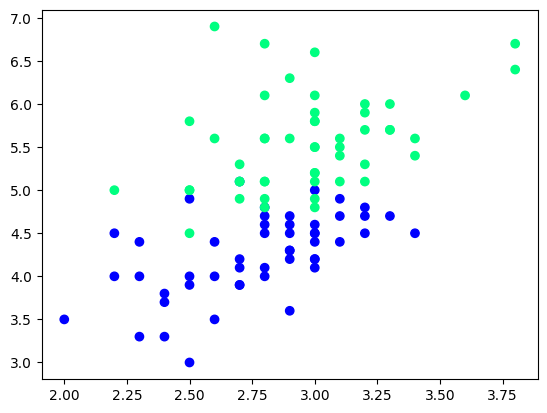

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.scatter(df['sepal width (cm)'], df['petal length (cm)'], c=df['species'], cmap='winter')

In [45]:
# Taking only 10 rows for training
df = df.sample(100)  # It will Randomly disperse the data
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [47]:
df_train

,sepal width (cm),petal length (cm),species
145,3.0,5.2,2
117,3.8,6.7,2
111,2.7,5.3,2
63,2.9,4.7,1
123,2.7,4.9,2
95,3.0,4.2,1
149,3.0,5.1,2
139,3.1,5.4,2
115,3.2,5.3,2
140,3.1,5.6,2


In [48]:
df_val

,sepal width (cm),petal length (cm),species
124,3.3,5.7,2
60,2.0,3.5,1
70,3.2,4.8,1
130,2.8,6.1,2
116,3.0,5.5,2


In [49]:
df_test

,sepal width (cm),petal length (cm),species
122,2.8,6.7,2
82,2.7,3.9,1
90,2.6,4.4,1
80,2.4,3.8,1
113,2.5,5.0,2


# Case 1. Bagging 
In Bagging same rows can come with multiple times, it means row sampling with replacement

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [50]:
# validation data
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [56]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test, y_pred))

In [54]:
# Data for tree 1 
df_bag = df_train.sample(8, replace=True) # from size of 10 we take only 8 and any row can come multiple times 
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),species
117,3.8,6.7,2
123,2.7,4.9,2
111,2.7,5.3,2
111,2.7,5.3,2
115,3.2,5.3,2
63,2.9,4.7,1
139,3.1,5.4,2
117,3.8,6.7,2


In [57]:
dt_bag1 = DecisionTreeClassifier()

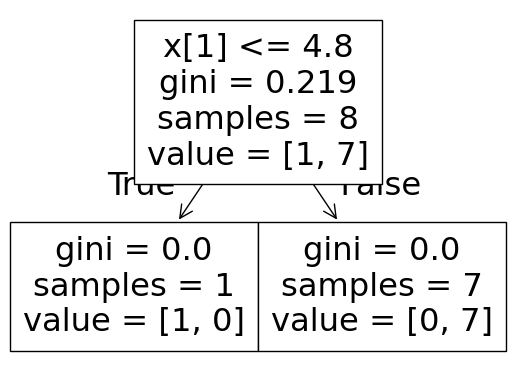

/home/kali/miniconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/kali/miniconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


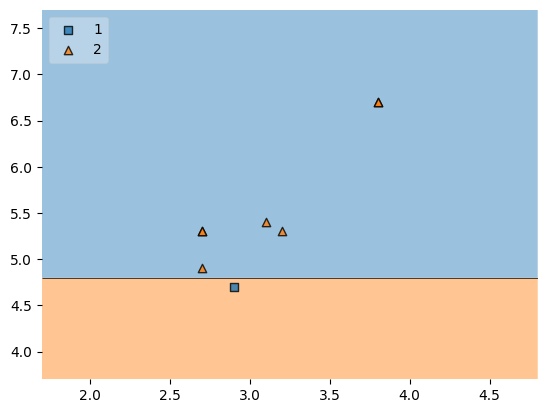

In [60]:
evaluate(dt_bag1,X,y)

In [61]:
# Data for tree 2
df_bag = df_train.sample(8, replace=True) # from size of 10 we take only 8 and any row can come multiple times 
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),species
145,3.0,5.2,2
140,3.1,5.6,2
117,3.8,6.7,2
139,3.1,5.4,2
123,2.7,4.9,2
95,3.0,4.2,1
95,3.0,4.2,1
140,3.1,5.6,2


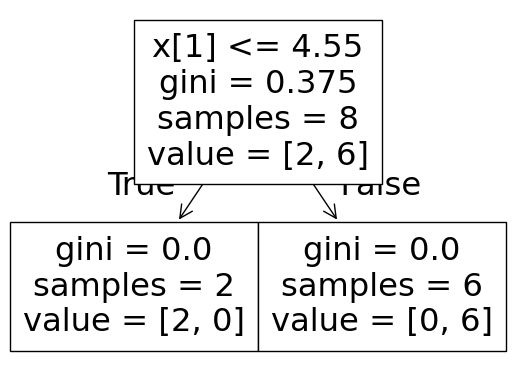

/home/kali/miniconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/kali/miniconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


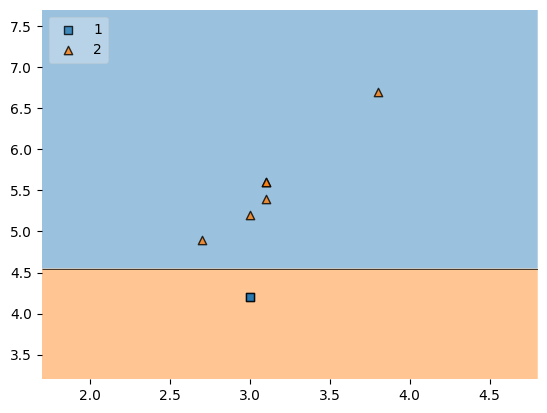

In [62]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [64]:
# Data for tree 3
df_bag = df_train.sample(8, replace=True) # from size of 10 we take only 8 and any row can come multiple times 
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),species
139,3.1,5.4,2
111,2.7,5.3,2
149,3.0,5.1,2
115,3.2,5.3,2
140,3.1,5.6,2
117,3.8,6.7,2
115,3.2,5.3,2
139,3.1,5.4,2


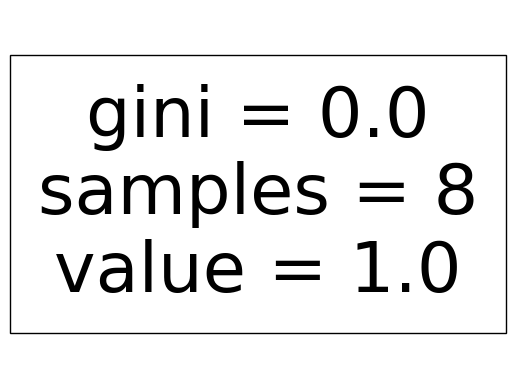

/home/kali/miniconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/kali/miniconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


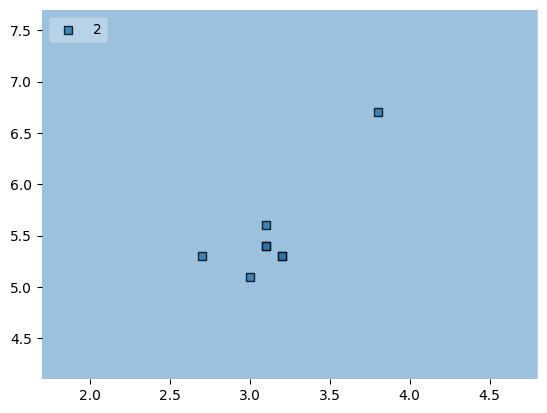

In [65]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

# Prediction

In [66]:
df_test

,sepal width (cm),petal length (cm),species
122,2.8,6.7,2
82,2.7,3.9,1
90,2.6,4.4,1
80,2.4,3.8,1
113,2.5,5.0,2


In [71]:
import numpy as np
print('Predictor 1 : ', dt_bag1.predict(np.array([2.7,3.9]).reshape(1,2)))
print('Predictor 2 : ', dt_bag2.predict(np.array([2.7,3.9]).reshape(1,2)))
print('Predictor 3 : ', dt_bag3.predict(np.array([2.7,3.9]).reshape(1,2)))

Predictor 1 :  [1]
Predictor 2 :  [1]
Predictor 3 :  [2]


/home/kali/miniconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/kali/miniconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/kali/miniconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Case 2. Pasting 
In this same row can't come multiple times, it means rows without replacement

In [72]:
df_train 

,sepal width (cm),petal length (cm),species
145,3.0,5.2,2
117,3.8,6.7,2
111,2.7,5.3,2
63,2.9,4.7,1
123,2.7,4.9,2
95,3.0,4.2,1
149,3.0,5.1,2
139,3.1,5.4,2
115,3.2,5.3,2
140,3.1,5.6,2


In [75]:
df_train.sample(8) # by default replace=False

,sepal width (cm),petal length (cm),species
145,3.0,5.2,2
63,2.9,4.7,1
111,2.7,5.3,2
123,2.7,4.9,2
139,3.1,5.4,2
149,3.0,5.1,2
140,3.1,5.6,2
117,3.8,6.7,2


# Case 3. Random Subspaces 
It keeps all training instances along rows but sampling a random subset of features (columns) means Column Sampling 

In [90]:
iris1 = load_iris()
df1 = pd.DataFrame(data=iris1.data, columns=iris1.feature_names)
df1['species']=iris1.target
df1[0:2]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0


In [91]:
df1 = df1.sample(10)
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
74,6.4,2.9,4.3,1.3,1
142,5.8,2.7,5.1,1.9,2
81,5.5,2.4,3.7,1.0,1
9,4.9,3.1,1.5,0.1,0
6,4.6,3.4,1.4,0.3,0
19,5.1,3.8,1.5,0.3,0
40,5.0,3.5,1.3,0.3,0
106,4.9,2.5,4.5,1.7,2
42,4.4,3.2,1.3,0.2,0
128,6.4,2.8,5.6,2.1,2


In [92]:
df1.sample(2, replace=True, axis=1) # it will randomly take any two column's

,species,petal width (cm)
74,1,1.3
142,2,1.9
81,1,1.0
9,0,0.1
6,0,0.3
19,0,0.3
40,0,0.3
106,2,1.7
42,0,0.2
128,2,2.1


# Case 4. Random Patches
Random patches is a hybrid method that creates diversity by sampling both training instances (rows) and features (columns)

In [93]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
74,6.4,2.9,4.3,1.3,1
142,5.8,2.7,5.1,1.9,2
81,5.5,2.4,3.7,1.0,1
9,4.9,3.1,1.5,0.1,0
6,4.6,3.4,1.4,0.3,0
19,5.1,3.8,1.5,0.3,0
40,5.0,3.5,1.3,0.3,0
106,4.9,2.5,4.5,1.7,2
42,4.4,3.2,1.3,0.2,0
128,6.4,2.8,5.6,2.1,2


In [98]:
df1.sample(8, replace=True).sample(2,replace=True,axis=1) # first part=row_sampling, second part=column_sampling

,species,sepal length (cm)
106,2,4.9
9,0,4.9
74,1,6.4
40,0,5.0
19,0,5.1
106,2,4.9
19,0,5.1
81,1,5.5
